## TC 5033
### Word Embeddings

<br>

#### Activity 3a: Exploring Word Embeddings with GloVe and Numpy
<br>

- Objective:
    - To understand the concept of word embeddings and their significance in Natural Language Processing.
    - To learn how to manipulate and visualize high-dimensional data using dimensionality reduction techniques like PCA and t-SNE.
    - To gain hands-on experience in implementing word similarity and analogies using GloVe embeddings and Numpy.
    
<br>

- Instructions:
    - Download GloVe pre-trained vectors from the provided link in Canvas, the official public project:
    Jeffrey Pennington, Richard Socher, and Christopher D. Manning. 2014. GloVe: Global Vectors for Word Representation
    https://nlp.stanford.edu/data/glove.6B.zip

    - Create a dictorionay of the embeddings so that you carry out fast look ups. Save that dictionary e.g. as a serialized file for faster loading in future uses.
    
    - PCA and t-SNE Visualization: After loading the GloVe embeddings, use Numpy and Sklearn to perform PCA and t-SNE to reduce the dimensionality of the embeddings and visualize them in a 2D or 3D space.

    - Word Similarity: Implement a function that takes a word as input and returns the 'n' most similar words based on their embeddings. You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Word Analogies: Implement a function to solve analogies between words. For example, "man is to king as woman is to ____". You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Submission: This activity is to be submitted in teams of 3 or 4. Only one person should submit the final work, with the full names of all team members included in a markdown cell at the beginning of the notebook.
    
<br>

- Evaluation Criteria:

    - Code Quality (40%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity.
    
   - Functionality (60%): All functions should work as intended, without errors.
       - Visualization of PCA and t-SNE (10% each for a total of 20%)
       - Similarity function (20%)
       - Analogy function (20%)
|



#### Import libraries

*  Equipo 54:
    
    
    *   Fanny Betsabé Fuentes Reyes - A00570705
    *   Leonel Matus Climaco - A01797557
    *   Fernando Omar Salazar Ortiz - A01796214
    *   Quirec Angeles Martinez - A01745050
    

In [55]:
# Import libraries
import torch
import torch.nn.functional as F
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import norm
import pickle
plt.style.use('ggplot')

#### Load file

In [56]:
# PATH = '/media/pepe/DataUbuntu/Databases/glove_embeddings/glove.6B.200d.txt'
PATH = '/content/sample_data/glove.6B.100d.txt'
emb_dim = 100

In [57]:
# Create dictionary with embeddings
def create_emb_dictionary(path):
    embeddings = {}
    print(f"Reading embeddings from {path}...")

    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            # Convert the vector part to a numpy array of floats
            vector = np.array(values[1:], dtype='float32')
            embeddings[word] = vector

    print(f"Successfully loaded {len(embeddings)} word vectors.")
    return embeddings


In [58]:
# create dictionary
embeddings_dict = create_emb_dictionary(PATH)

Reading embeddings from /content/sample_data/glove.6B.100d.txt...
Successfully loaded 400000 word vectors.


In [59]:
# Serialize
with open('embeddings_dict_50D.pkl', 'wb') as f:
    pickle.dump(embeddings_dict, f)

# Deserialize
# with open('embeddings_dict_200D.pkl', 'rb') as f:
#     embeddings_dict = pickle.load(f)

#### See some embeddings

In [60]:
# Show some
def show_n_first_words(path, n_words):
        with open(path, 'r') as f:
            for i, line in enumerate(f):
                print(line.split(), len(line.split()[1:]))
                if i>=n_words: break

In [61]:
show_n_first_words(PATH, 5)

['the', '-0.038194', '-0.24487', '0.72812', '-0.39961', '0.083172', '0.043953', '-0.39141', '0.3344', '-0.57545', '0.087459', '0.28787', '-0.06731', '0.30906', '-0.26384', '-0.13231', '-0.20757', '0.33395', '-0.33848', '-0.31743', '-0.48336', '0.1464', '-0.37304', '0.34577', '0.052041', '0.44946', '-0.46971', '0.02628', '-0.54155', '-0.15518', '-0.14107', '-0.039722', '0.28277', '0.14393', '0.23464', '-0.31021', '0.086173', '0.20397', '0.52624', '0.17164', '-0.082378', '-0.71787', '-0.41531', '0.20335', '-0.12763', '0.41367', '0.55187', '0.57908', '-0.33477', '-0.36559', '-0.54857', '-0.062892', '0.26584', '0.30205', '0.99775', '-0.80481', '-3.0243', '0.01254', '-0.36942', '2.2167', '0.72201', '-0.24978', '0.92136', '0.034514', '0.46745', '1.1079', '-0.19358', '-0.074575', '0.23353', '-0.052062', '-0.22044', '0.057162', '-0.15806', '-0.30798', '-0.41625', '0.37972', '0.15006', '-0.53212', '-0.2055', '-1.2526', '0.071624', '0.70565', '0.49744', '-0.42063', '0.26148', '-1.538', '-0.30223

### Plot some embeddings

In [62]:
def plot_embeddings(emb_path, words2show, emb_dim, embeddings_dict, func=PCA):
    # 1. Filter words that actually exist in your dictionary
    valid_words = [w for w in words2show if w in embeddings_dict]

    # 2. Create the matrix of vectors
    # We stack them into a 2D numpy array
    matrix = np.array([embeddings_dict[w] for w in valid_words])

    # 3. Dimensionality Reduction
    # We instantiate the class passed in 'func'
    # For t-SNE, we need to set perplexity.
    # We use a conditional check to handle parameters if needed.
    if func.__name__ == 'TSNE':
        # t-SNE needs a perplexity smaller than the number of samples
        n_samples = len(valid_words)
        reducer = func(n_components=2, perplexity=min(n_samples - 1, 30), random_state=42, init='pca', learning_rate='auto')
    else:
        reducer = func(n_components=2)

    reduced_data = reducer.fit_transform(matrix)

    # 4. Plotting
    plt.figure(figsize=(10, 6))
    plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c='blue', alpha=0.6)

    for i, word in enumerate(valid_words):
        plt.annotate(word, (reduced_data[i, 0], reduced_data[i, 1]), fontsize=10)

    plt.title(f'Visualization using {func.__name__}')
    plt.grid(True)
    plt.show()

In [63]:
words= ['burger', 'tortilla', 'bread', 'pizza', 'beef', 'steak', 'fries', 'chips',
            'argentina', 'mexico', 'spain', 'usa', 'france', 'italy', 'greece', 'china',
            'water', 'beer', 'tequila', 'wine', 'whisky', 'brandy', 'vodka', 'coffee', 'tea',
            'apple', 'banana', 'orange', 'lemon', 'grapefruit', 'grape', 'strawberry', 'raspberry',
            'school', 'work', 'university', 'highschool']


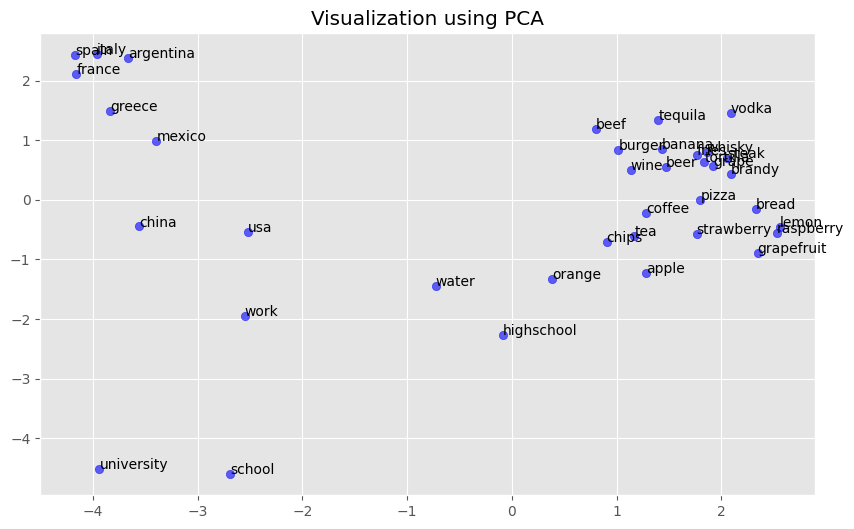

In [64]:
#
plot_embeddings(PATH, words, emb_dim, embeddings_dict, PCA)

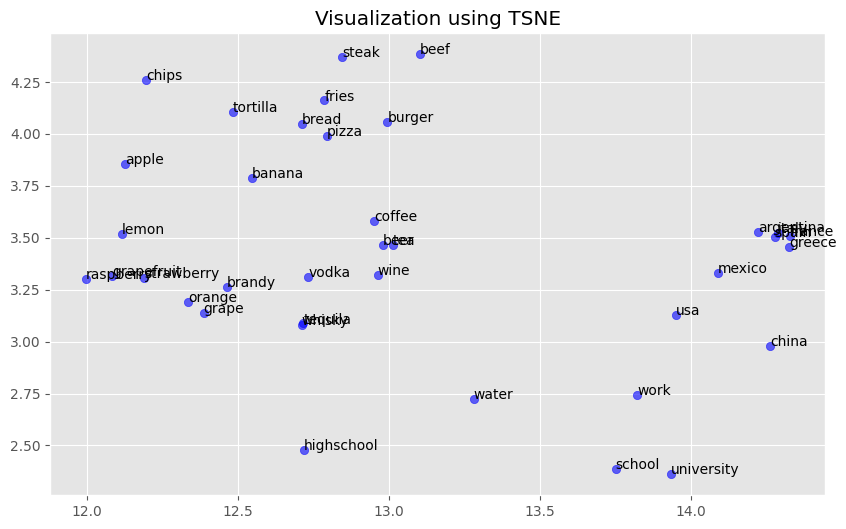

In [65]:
# t-SNE dimensionality reduction for visualization
embeddings = plot_embeddings(PATH, words, emb_dim, embeddings_dict, TSNE)

### Let us compute analogies

To solve the analogy "word1 is to word2 as word3 is to [?]", we need to find the word whose vector is closest to the result of the vector arithmetic: $vec(word2) - vec(word1) + vec(word3)$.

In [66]:
def analogy(word1, word2, word3, embeddings_dict, n=5):
    # 1. Ensure all words exist in the dictionary
    if not all(w in embeddings_dict for w in [word1, word2, word3]):
        return "One or more words not found in dictionary."

    # 2. Calculate the target vector
    target_vec = embeddings_dict[word2] - embeddings_dict[word1] + embeddings_dict[word3]

    # 3. Calculate Cosine Similarity for all words
    # We use a dictionary to store similarities: {word: similarity_score}
    similarities = {}

    # Pre-calculate target norm for efficiency
    target_norm = np.linalg.norm(target_vec)

    for word, vec in embeddings_dict.items():
        # Skip the input words themselves
        if word in [word1, word2, word3]:
            continue

        # Cosine Similarity: (A . B) / (||A|| * ||B||)
        dot_product = np.dot(target_vec, vec)
        vec_norm = np.linalg.norm(vec)

        # Avoid division by zero
        if vec_norm == 0: continue

        similarity = dot_product / (target_norm * vec_norm)
        similarities[word] = similarity

    # 4. Sort by similarity (highest first)
    sorted_similarities = sorted(similarities.items(), key=lambda item: item[1], reverse=True)

    return sorted_similarities[:n]

In [67]:
analogy('man', 'king', 'woman', embeddings_dict)

[('queen', np.float32(0.7834413)),
 ('monarch', np.float32(0.6933802)),
 ('throne', np.float32(0.6833111)),
 ('daughter', np.float32(0.6809082)),
 ('prince', np.float32(0.67131424))]

In [68]:
# most similar
def find_most_similar(word, embeddings_dict, top_n=10):
    # 1. Check if the word exists
    if word not in embeddings_dict:
        return f"Error: '{word}' not found in the dictionary."

    # 2. Get the target vector and its norm
    target_vec = embeddings_dict[word]
    target_norm = np.linalg.norm(target_vec)

    # 3. Calculate similarities for all words
    similarities = {}
    for w, vec in embeddings_dict.items():
        if w == word:
            continue

        # Cosine Similarity: (A · B) / (||A|| * ||B||)
        vec_norm = np.linalg.norm(vec)

        # Avoid division by zero
        if vec_norm == 0:
            continue

        cosine_sim = np.dot(target_vec, vec) / (target_norm * vec_norm)
        similarities[w] = cosine_sim

    # 4. Sort by similarity score (highest first)
    # We use a lambda to sort by the value (similarity) in descending order
    sorted_similarities = sorted(similarities.items(), key=lambda item: item[1], reverse=True)

    # 5. Return the top N
    return sorted_similarities[:top_n]

In [69]:
most_similar = find_most_similar('mexico', embeddings_dict)

In [70]:
for i, w in enumerate(most_similar, 1):
    print(f'{i} ---> {w[0]}')

1 ---> brazil
2 ---> peru
3 ---> venezuela
4 ---> colombia
5 ---> rico
6 ---> puerto
7 ---> mexican
8 ---> chile
9 ---> argentina
10 ---> guatemala
